
# Séance 6 Août — Classification pratique (Dataset : **Crédit Bancaire**)

- Choisir **quand** et **quel** algorithme de classification utiliser.
- Réaliser tout le **préprocessing** des 4 premières séances avant de modéliser.
- Construire des **pipelines** robustes (imputation, encodage, scaling) et évaluer avec **validation croisée stratifiée**.
- Maîtriser les **métriques** (accuracy, precision, recall, F1, ROC/PR) et le **seuil de décision**.
- Interpréter.


# Importing all the libraries needed

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
from sklearn import preprocessing
import matplotlib
matplotlib.style.use('ggplot')
from sklearn.preprocessing import LabelEncoder

# Context

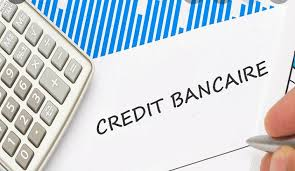


| Variable           | Définition                                                       |
| ------------------ | ---------------------------------------------------------------- |
| Age                | Âge de la personne (en années).                                  |
| Gender             | Genre déclaré de la personne.                                    |
| Income             | Revenu de la personne (montant, idéalement annuel).              |
| Education          | Niveau d’études atteint.                                         |
| Marital Status     | Statut matrimonial (célibataire, marié·e, etc.).                 |
| Number of Children | Nombre d’enfants à charge.                                       |
| Home Ownership     | Statut d’occupation du logement (propriétaire, locataire, etc.). |
| got\_credit        | Cible binaire : vaut 1 si le crédit est accordé, 0 sinon. |


In [2]:
# Télécharger le fichier CSV directement depuis GitHub
!wget https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_6_Classification/Datasets/credit.csv

--2025-09-09 20:40:28--  https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_6_Classification/Datasets/credit.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8251 (8.1K) [text/plain]
Saving to: ‘credit.csv.2’

credit.csv.2        100%[===================>]   8.06K  --.-KB/s    in 0s      

2025-09-09 20:40:28 (69.5 MB/s) - ‘credit.csv.2’ saved [8251/8251]



In [3]:
# Ouvrir les données dans df
df = pd.read_csv("credit.csv")

In [4]:
df.head()

,Age,Gender,Income,Education,Marital_Status,Number_of_Children,Home_Ownership,got_credit
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,1
1,30,Male,100000,Master's Degree,Married,2,Owned,1
2,35,Female,75000,Doctorate,Married,1,Owned,1
3,40,Male,125000,High School Diploma,Single,0,Owned,1
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,1


In [5]:
df.shape

(164, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital_Status      164 non-null    object
 5   Number_of_Children  164 non-null    int64 
 6   Home_Ownership      164 non-null    object
 7   got_credit          164 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 10.4+ KB


# Exploratory Data Analysis

<img src="https://media.giphy.com/media/HUplkVCPY7jTW/giphy.gif">


In [7]:
# vérifions les données manquantes
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Education,0
Marital_Status,0
Number_of_Children,0
Home_Ownership,0
got_credit,0


In [8]:
df.duplicated().sum()

np.int64(62)

In [9]:
# Calculons la proportion des doublons
df.duplicated().sum()/df.shape[0]*100

np.float64(37.80487804878049)

In [10]:
# verifier les doublons
# En absence des identifiants
# Supposons que ce ne sont pas les même personnes qui sont répétées

# H1 : Il est peu probable que les même personnes reviennent au point où on ait 338% de doublons
# Donc les doublons identifiés sont en réalité différentes personnes avec les mêmes caratéristiques

# Au final, nous gardons les lignes identifiées comme doublons dans notre jeu de données

In [11]:
#Décrire les données selon le type de data :
  #pour les données quantitatives
df.describe()

,Age,Income,Number_of_Children,got_credit
count,164.000000,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439,0.689024
std,8.477289,32457.306728,0.883346,0.464311
min,25.000000,25000.000000,0.000000,0.000000
25%,30.750000,57500.000000,0.000000,0.000000
50%,37.000000,83750.000000,0.000000,1.000000
75%,45.000000,105000.000000,1.000000,1.000000
max,53.000000,162500.000000,3.000000,1.000000


In [12]:
#Décrire les données selon le type de data :
  #pour les données quantitatives
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,164.0,37.975610,8.477289,25.0,30.75,37.0,45.0,53.0
Income,164.0,83765.243902,32457.306728,25000.0,57500.00,83750.0,105000.0,162500.0
Number_of_Children,164.0,0.652439,0.883346,0.0,0.00,0.0,1.0,3.0
got_credit,164.0,0.689024,0.464311,0.0,0.00,1.0,1.0,1.0


In [13]:
#pour les données catégorielles
df.describe(include='object').T

,count,unique,top,freq
Gender,164,2,Female,86
Education,164,5,Bachelor's Degree,42
Marital_Status,164,2,Married,87
Home_Ownership,164,2,Owned,111


In [14]:
# Valeurs abérantes

In [15]:
# Selection les colunnes numeriques
num_col=df.select_dtypes(include=np.number).columns
num_col

Index(['Age', 'Income', 'Number_of_Children', 'got_credit'], dtype='object')

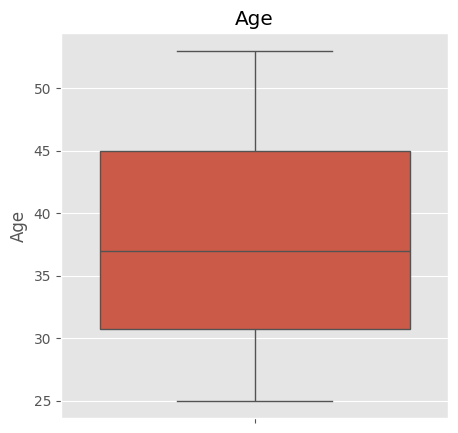

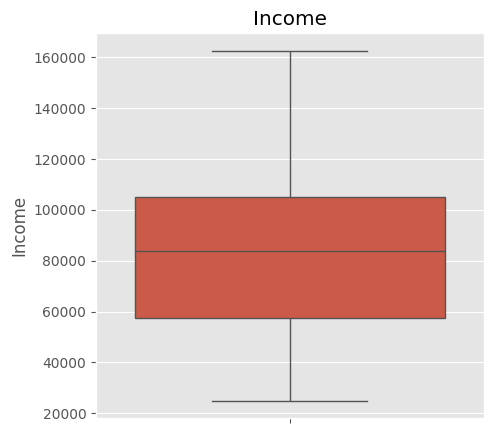

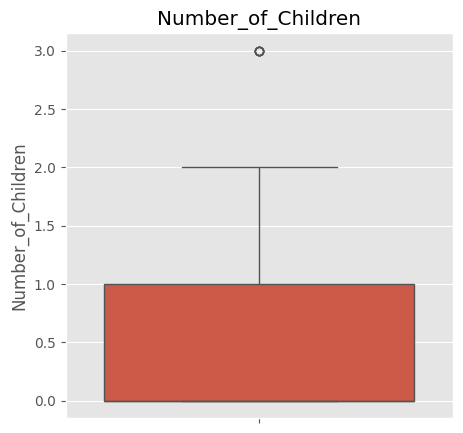

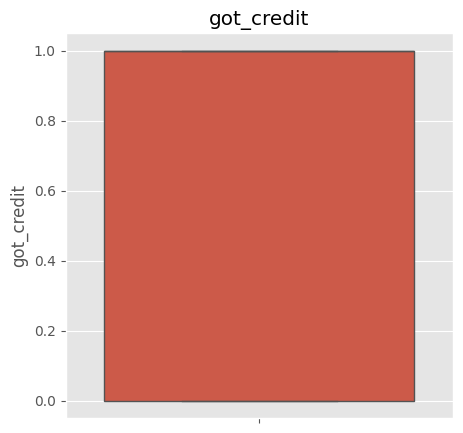

In [16]:
# Pour chaque colunne numérique, faire le boxplot
for col in num_col:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [17]:
df['Number_of_Children'].value_counts()

,count
Number_of_Children,
0,97
1,32
2,30
3,5


In [18]:
# Calculer la correlation entre les variables numeriques
df[num_col].corr()

,Age,Income,Number_of_Children,got_credit
Age,1.000000,0.699464,0.055390,0.707244
Income,0.699464,1.000000,0.084547,0.730332
Number_of_Children,0.055390,0.084547,1.000000,0.452844
got_credit,0.707244,0.730332,0.452844,1.000000


<Axes: >

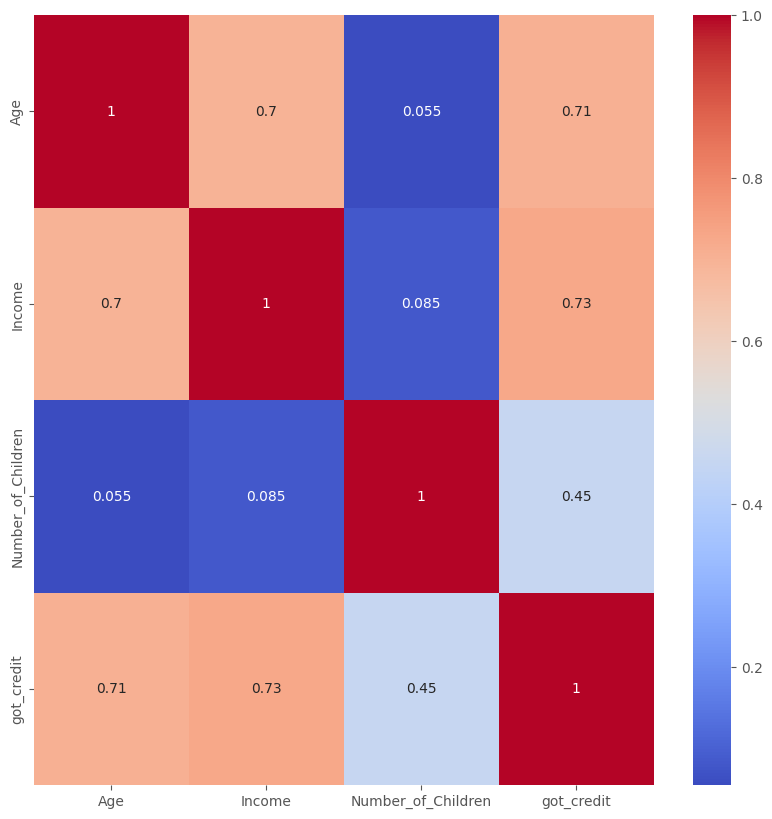

In [19]:
# Faire un heatmap de la correlation
plt.figure(figsize=(10,10))
sns.heatmap(df[num_col].corr(),annot=True,cmap='coolwarm')

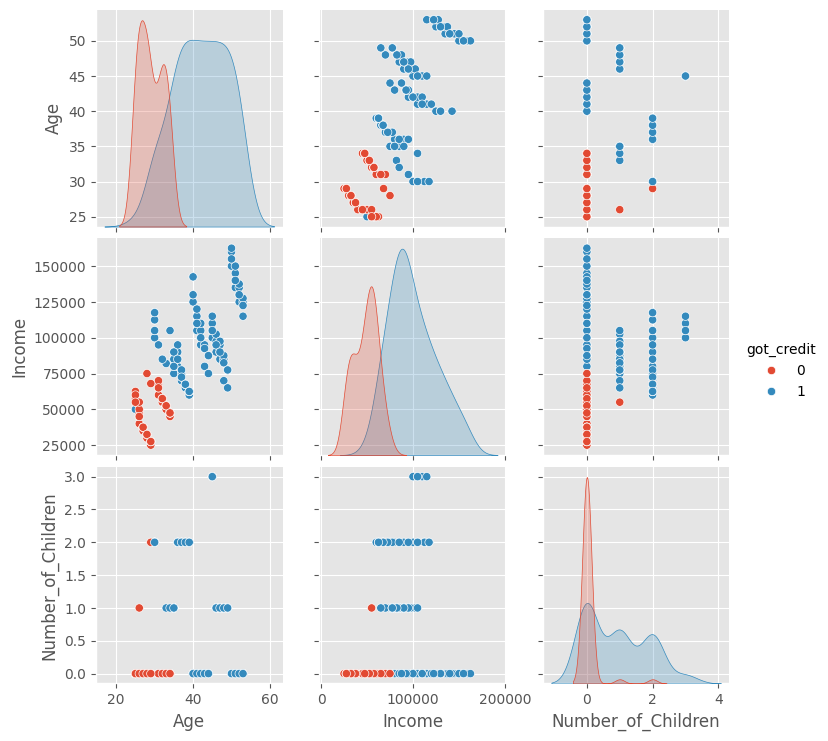

In [20]:
# Faire le pairplot de df en utilisant got_credit comme hue
sns.pairplot(df,hue='got_credit')

In [21]:
# Selectionner les variables qualitatives
cat_col=df.select_dtypes(exclude=np.number).columns
cat_col

Index(['Gender', 'Education', 'Marital_Status', 'Home_Ownership'], dtype='object')

In [22]:
# Faire le value_count sur cat_col
for col in cat_col:
  print("--------------")
  print(df[col].value_counts())
  print("--------------")
  print(df[col].value_counts(normalize=True))
  print("--------------")

--------------
Gender
Female    86
Male      78
Name: count, dtype: int64
--------------
Gender
Female    0.52439
Male      0.47561
Name: proportion, dtype: float64
--------------
--------------
Education
Bachelor's Degree      42
Master's Degree        36
Doctorate              31
High School Diploma    30
Associate's Degree     25
Name: count, dtype: int64
--------------
Education
Bachelor's Degree      0.256098
Master's Degree        0.219512
Doctorate              0.189024
High School Diploma    0.182927
Associate's Degree     0.152439
Name: proportion, dtype: float64
--------------
--------------
Marital_Status
Married    87
Single     77
Name: count, dtype: int64
--------------
Marital_Status
Married    0.530488
Single     0.469512
Name: proportion, dtype: float64
--------------
--------------
Home_Ownership
Owned     111
Rented     53
Name: count, dtype: int64
--------------
Home_Ownership
Owned     0.676829
Rented    0.323171
Name: proportion, dtype: float64
--------------


# 2. Gestion des variables catégorielles

Les variables catégorielles peuvent être classées en deux grandes catégories :

- **Nominales**  
- **Ordinales**

## 🧠 Quelle méthode utiliser ?

### 🔷 Pour les **modèles non basés sur les arbres** (régression logistique, SVM, KNN, etc.)

➡️ **Utiliser One-Hot Encoding**

- ✅ Avantage : résultat binaire, pas d’ordre artificiel, **vecteurs orthogonaux**.
- ❌ Inconvénient : en cas de **haute cardinalité**, le nombre de colonnes explose → **malédiction de la dimensionnalité**.

📌 **Astuce** : on peut combiner **One-Hot Encoding + PCA** pour réduire la dimension tout en capturant les regroupements de catégories similaires.

---

### 🟩 Pour les **modèles basés sur les arbres** (arbres de décision, forêts aléatoires, etc.)

➡️ **Utiliser Label Encoding**

- Exemple : `['dog', 'cat', 'mouse']` → `[1, 2, 3]`
- ⚠️ Cela introduit un **ordre numérique artificiel**, mais les arbres s’en accommodent bien car ils traitent les variables de manière indépendante.

✅ `LabelEncoder` est aussi **plus léger** (moins de colonnes) et adapté aux arbres de décision.

---

### 📝 Récapitulatif

| Type de modèle                                            | Encodage recommandé   |
|-----------------------------------------------------------|------------------------|
| Modèles **non-arbres** (LogReg, SVM, KNN, etc.)           | ✅ One-Hot Encoding     |
| Modèles **à base d’arbres** (Tree, Random Forest, XGBoost)| ✅ Label Encoding       |


In [23]:
# Faire le one hot-encoding sur les données
df_non_tree=pd.get_dummies(df,drop_first=False)
df_non_tree.head()

,Age,Income,Number_of_Children,got_credit,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital_Status_Married,Marital_Status_Single,Home_Ownership_Owned,Home_Ownership_Rented
0,25,50000,0,1,True,False,False,True,False,False,False,False,True,False,True
1,30,100000,2,1,False,True,False,False,False,False,True,True,False,True,False
2,35,75000,1,1,True,False,False,False,True,False,False,True,False,True,False
3,40,125000,0,1,False,True,False,False,False,True,False,False,True,True,False
4,45,100000,3,1,True,False,False,True,False,False,False,True,False,True,False


In [24]:
# Faire le one hot-encoding sur les données en utilisant le OneHotEconding de sklearn.preprocessing
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
df_non_tree_2 = ohe.fit_transform(df[cat_col])

In [25]:
df_non_tree_2 = pd.DataFrame(df_non_tree_2.toarray(),columns=ohe.get_feature_names_out())
df_non_tree_2.head()

,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital_Status_Married,Marital_Status_Single,Home_Ownership_Owned,Home_Ownership_Rented
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [26]:
df_non_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            164 non-null    int64
 1   Income                         164 non-null    int64
 2   Number_of_Children             164 non-null    int64
 3   got_credit                     164 non-null    int64
 4   Gender_Female                  164 non-null    bool 
 5   Gender_Male                    164 non-null    bool 
 6   Education_Associate's Degree   164 non-null    bool 
 7   Education_Bachelor's Degree    164 non-null    bool 
 8   Education_Doctorate            164 non-null    bool 
 9   Education_High School Diploma  164 non-null    bool 
 10  Education_Master's Degree      164 non-null    bool 
 11  Marital_Status_Married         164 non-null    bool 
 12  Marital_Status_Single          164 non-null    bool 
 13  Home_Ownership_Owned

In [27]:
# Faire le lebel encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_tree=df.copy()
for col in cat_col:
  df_tree[col]=le.fit_transform(df_tree[col])
df_tree.head()

,Age,Gender,Income,Education,Marital_Status,Number_of_Children,Home_Ownership,got_credit
0,25,0,50000,1,1,0,1,1
1,30,1,100000,4,0,2,0,1
2,35,0,75000,2,0,1,0,1
3,40,1,125000,3,1,0,0,1
4,45,0,100000,1,0,3,0,1


# 3. Feature Scaling


### Pourquoi utiliser la mise à l’échelle des variables ?

La première question à se poser est la suivante : pourquoi devons-nous mettre à l’échelle les variables de notre jeu de données ?  
Certains algorithmes d’apprentissage automatique sont **sensibles** à la mise à l’échelle des caractéristiques, tandis que d’autres y sont quasiment **invariants**. Voici plus de détails.

---

## 1. Algorithmes fondés sur la distance

Les algorithmes de distance comme **KNN**, **K-means** et **SVM** sont les plus affectés par l’échelle des variables.  
En coulisses, ils utilisent des **distances entre points** pour mesurer leur similarité.

Lorsque deux variables n’ont pas la même échelle, il y a un risque que les variables de grande amplitude reçoivent un poids plus élevé.  
Cela peut dégrader les performances de l’algorithme et introduire un **biais** non désiré.

➡️ **On met donc les variables à la même échelle** avant d’utiliser un algorithme basé sur la distance, afin que **chaque variable contribue équitablement** au calcul.


<img src="https://miro.medium.com/max/1000/0*MZKG8sTIdSNv6TXB" width=50%>


## 2. Algorithmes à base d’arbres

Les algorithmes à base d’arbres, en revanche, sont généralement **insensibles à l’échelle** des variables.

Un arbre de décision **scinde un nœud** en fonction d’une seule variable, en choisissant la valeur qui maximise l’homogénéité du sous-groupe.  
Cette décision **ne dépend pas** des autres variables ni de leurs échelles.

✅ C’est pourquoi les arbres (et forêts) ne nécessitent **aucune mise à l’échelle** des variables en entrée.

<img src="https://miro.medium.com/max/925/0*U0rcW7XrdHpvI0hU.jpeg" width=70%>

### Qu’est-ce que la normalisation ?

La **normalisation** est une technique de mise à l’échelle dans laquelle les valeurs sont **décalées et rescalées** pour être comprises entre **0 et 1**.  
On l’appelle aussi **mise à l’échelle Min-Max**.

La formule de la normalisation est la suivante :

<img src="https://i.stack.imgur.com/EuitP.png" width=40%>

> Où `Xmax` et `Xmin` sont respectivement les **valeurs maximale et minimale** de la variable.

---

- Lorsque `X` est égal à **Xmin**, le numérateur vaut 0 → la valeur normalisée **X' = 0**
- Lorsque `X` est égal à **Xmax**, le numérateur = dénominateur → donc **X' = 1**
- Si `X` est **entre** Xmin et Xmax, alors **X' sera compris entre 0 et 1**

✅ La normalisation est **particulièrement utile** lorsque l’on veut que **toutes les variables soient ramenées à une échelle commune**, en particulier pour les algorithmes sensibles aux distances (KNN, SVM, etc.).

## Qu’est-ce que la standardisation ?

La **standardisation** est une autre technique de mise à l’échelle, dans laquelle les valeurs sont **centrées autour de la moyenne** et **réduites à une unité d’écart-type**.  
Cela signifie que la **moyenne devient 0** et que la **distribution résultante a un écart-type égal à 1**.

Voici la formule de la standardisation :

<img src="https://clavelresearch.files.wordpress.com/2019/03/z-score-population.png" width=30%>

---

## La grande question : Normaliser ou Standardiser ?

La question **normalisation vs. standardisation** revient souvent chez les débutants en machine learning. Voici quelques repères pour choisir :

- ✅ **Normalisation** (Min-Max) est préférable **lorsque vos données ne suivent pas une distribution normale**.  
  Elle est utile pour des algorithmes **non paramétriques** comme **K-Nearest Neighbors** ou les **réseaux de neurones**, qui ne font **aucune hypothèse sur la distribution** des données.

- ✅ **Standardisation** est plus adaptée **si les données suivent une distribution gaussienne (normale)**.  
  Mais ce n’est pas une obligation stricte. Contrairement à la normalisation, la standardisation **ne contraint pas les valeurs entre 0 et 1**.  
  Ainsi, les **valeurs extrêmes (outliers)** auront **moins d’impact** après standardisation qu’après normalisation.

---

🎯 **Conclusion** : le choix entre normalisation et standardisation **dépend du problème** et de l’algorithme utilisé.  
Il n’existe **pas de règle absolue**. Il faut tester et évaluer selon le cas.


### Robust Scaler

Lorsqu’on travaille avec des données contenant des **valeurs aberrantes (outliers)**, il est préférable d’utiliser un **scaling robuste** comme `RobustScaler`.

Cette méthode utilise des **statistiques robustes**, c’est-à-dire **moins sensibles aux valeurs extrêmes**.  
Concrètement, elle :

- **soustrait la médiane** de chaque variable  
- puis **divise par l’intervalle interquartile (IQR)**, c’est-à-dire la différence entre le **3ᵉ quartile (Q3)** et le **1er quartile (Q1)**  
  👉 autrement dit, elle **centre les données** et les met à l’échelle dans la plage **[Q1, Q3]**, soit entre le 25ᵉ et le 75ᵉ percentile.

---

✅ L’intérêt majeur du `RobustScaler` est sa **résistance aux valeurs extrêmes**.  
Contrairement à la standardisation (qui dépend de la moyenne et de l’écart-type), ce scaler **n’est pas influencé par quelques valeurs anormalement grandes ou petites**.

📌 Les valeurs de **médiane** et d’**IQR** calculées sont mémorisées pour être **réutilisées** sur de nouvelles données via la méthode `.transform()`.

---

🎯 À retenir :  
Si votre jeu de données contient des **outliers**, `RobustScaler` donne souvent de **meilleurs résultats** que la normalisation (`MinMaxScaler`) ou la standardisation (`StandardScaler`).


In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_non_tree[['Income', 'Age', 'Number_of_Children']] = scaler.fit_transform(df_non_tree[['Income', 'Age', 'Number_of_Children']])
df_non_tree.head()

,Age,Income,Number_of_Children,got_credit,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital_Status_Married,Marital_Status_Single,Home_Ownership_Owned,Home_Ownership_Rented
0,0.000000,0.181818,0.000000,1,True,False,False,True,False,False,False,False,True,False,True
1,0.178571,0.545455,0.666667,1,False,True,False,False,False,False,True,True,False,True,False
2,0.357143,0.363636,0.333333,1,True,False,False,False,True,False,False,True,False,True,False
3,0.535714,0.727273,0.000000,1,False,True,False,False,False,True,False,False,True,True,False
4,0.714286,0.545455,1.000000,1,True,False,False,True,False,False,False,True,False,True,False


In [29]:
df_non_tree

,Age,Income,Number_of_Children,got_credit,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital_Status_Married,Marital_Status_Single,Home_Ownership_Owned,Home_Ownership_Rented
0,0.000000,0.181818,0.000000,1,True,False,False,True,False,False,False,False,True,False,True
1,0.178571,0.545455,0.666667,1,False,True,False,False,False,False,True,True,False,True,False
2,0.357143,0.363636,0.333333,1,True,False,False,False,True,False,False,True,False,True,False
3,0.535714,0.727273,0.000000,1,False,True,False,False,False,True,False,False,True,True,False
4,0.714286,0.545455,1.000000,1,True,False,False,True,False,False,False,True,False,True,False
5,0.892857,0.909091,0.000000,1,False,True,False,False,False,False,True,True,False,True,False
6,0.035714,0.109091,0.000000,0,True,False,True,False,False,False,False,False,True,False,True
7,0.214286,0.254545,0.000000,0,False,True,False,True,False,False,False,False,True,False,True
8,0.392857,0.400000,0.666667,1,True,False,False,False,False,False,True,True,False,True,False
9,0.571429,0.581818,0.000000,1,False,True,False,False,True,False,False,False,True,True,False


# 4 - Choisir la bonne validation croisée

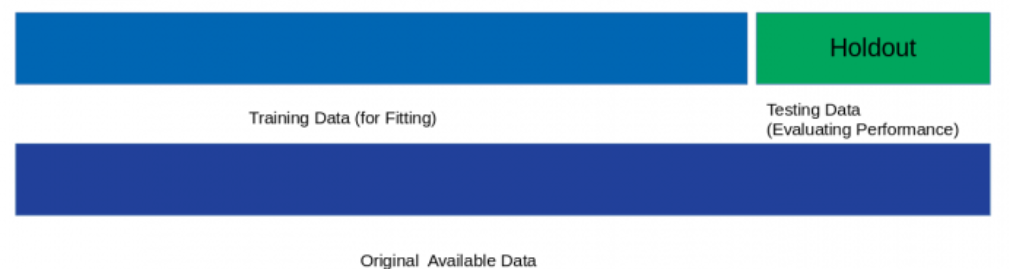

# 5 - Modélisation

# NON-TREE BASED ALGORITHMS

<img src="https://media.giphy.com/media/zMukICnMEZmSf8zvXd/giphy.gif">

## 1. Régression logistique

- **Principe** :  
  La régression logistique est un modèle linéaire qui estime la probabilité qu’une observation appartienne à une classe (ex. : 0 ou 1).  
  Elle utilise la **fonction sigmoïde** pour transformer une combinaison linéaire des variables en une probabilité comprise entre 0 et 1.

- **Avantages** :  
  - Facile à comprendre et interpréter (coefficients).  
  - Rapide à entraîner même sur de grands jeux de données.  
  - Probabilités bien calibrées.  

- **Limites** :  
  - Suppose une relation **linéaire** entre les variables et le logit.  
  - Moins performante sur des problèmes **non linéaires** complexes.  

- **Cas d’usage** :  
  - Problèmes de classification binaire (maladie : oui/non, défaut de paiement : oui/non).  
  - Quand l’**interprétabilité** est importante.

  Illustration

<img src="https://datatab.fr/assets/tutorial/linear_regression_equation.png">
Etape 2
<img src="https://datatab.fr/assets/tutorial/Derivation_of_the_Logistic_Regression.png">
Etape 3
<img src="https://datatab.fr/assets/tutorial/Logistic-function.png">

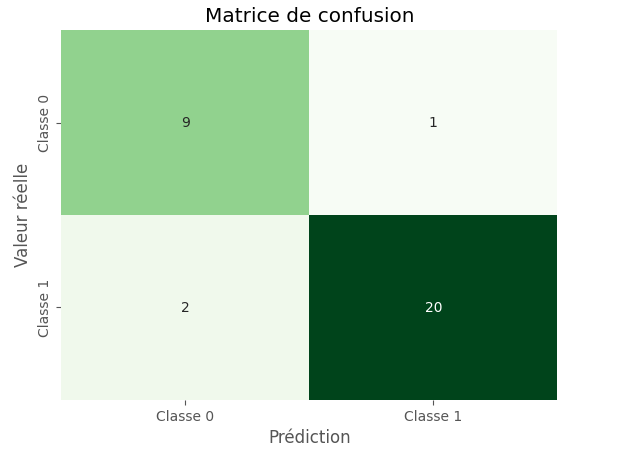

Voici une explication claire et concise de chaque **métrique d’évaluation**, avec leur **interprétation**, **utilité**, et **pièges à éviter** :

---

### ✅ `accuracy_score` → **Exactitude**

```python
acc = accuracy_score(y_valid, y_pred)
```

**Définition** : proportion de bonnes prédictions (positives et négatives) sur l’ensemble des prédictions.

**Formule** :

$$
\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}
$$

* **VP** : vrais positifs
* **VN** : vrais négatifs
* **FP** : faux positifs
* **FN** : faux négatifs

**🧠 Interprétation** : "Mon modèle prédit correctement X% des cas."

**⚠️ Limite** : pas fiable si les classes sont **déséquilibrées**.
Par exemple, avec 90% de classe 0, un modèle qui prédit toujours 0 aura 90% d’accuracy… mais ne détectera **jamais la classe 1**.

---

### ✅ `precision_score` → **Précision**

```python
prec = precision_score(y_valid, y_pred)
```

**Définition** : parmi toutes les **prédictions positives**, quelle proportion est correcte.

**Formule** :

$$
\text{Précision} = \frac{VP}{VP + FP}
$$

**🧠 Interprétation** : "Quand mon modèle dit ‘positif’, il a raison X% du temps."

**📌 Utile quand** les **faux positifs** sont coûteux.
Ex. : un email détecté comme spam alors qu’il ne l’est pas (perte d’un mail important).

---

### ✅ `recall_score` → **Rappel / Sensibilité**

```python
rec = recall_score(y_valid, y_pred)
```

**Définition** : parmi tous les **vrais cas positifs**, combien sont détectés par le modèle.

**Formule** :

$$
\text{Rappel} = \frac{VP}{VP + FN}
$$

**🧠 Interprétation** : "Mon modèle détecte X% des vrais cas positifs."

**📌 Utile quand** les **faux négatifs** sont critiques.
Ex. : ne pas détecter une fraude, une maladie, un défaut.

---

### ✅ `f1_score` → **Score F1**

```python
f1 = f1_score(y_valid, y_pred)
```

**Définition** : moyenne harmonique entre **précision** et **rappel**.

**Formule** :

$$
F1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}
$$

**🧠 Interprétation** : "Combinaison équilibrée entre rappel et précision."

**📌 Utile quand** tu veux un **compromis** entre les deux (ex. : détecter sans trop d’erreurs ni de ratés).

---

### ✅ `roc_auc_score` → **AUC (Area Under the ROC Curve)**

```python
roc_auc = roc_auc_score(y_valid, y_pred)
```

**Définition** : mesure la capacité du modèle à **distinguer les classes**, en tenant compte du **seuil de classification**.

**🧠 Interprétation** :
Probabilité qu’un exemple positif ait une **probabilité prédite plus haute** qu’un exemple négatif.

* 1.0 = parfait
* 0.5 = hasard
* < 0.5 = pire que le hasard (mauvais sens)

**📌 Utile pour** évaluer un modèle indépendamment du seuil (utilisé avec `predict_proba`).

---

### 🎯 En résumé :

| Métrique      | Question posée                                     | À privilégier quand…           |
| ------------- | -------------------------------------------------- | ------------------------------ |
| **Accuracy**  | Globalement, est-ce que mon modèle se trompe peu ? | Données équilibrées            |
| **Précision** | Quand il prédit “positif”, a-t-il raison ?         | Faux positifs coûteux          |
| **Rappel**    | Capte-t-il bien tous les vrais cas ?               | Faux négatifs risqués          |
| **F1-score**  | Fait-il un bon compromis entre les deux ?          | Objectif équilibré             |
| **ROC AUC**   | Distingue-t-il bien les classes en général ?       | Analyse globale de performance |


In [30]:
# Etape 1 - Importation des bibliotheques necessaires ppour faire la regression logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [31]:
df_non_tree.columns

Index(['Age', 'Income', 'Number_of_Children', 'got_credit', 'Gender_Female',
       'Gender_Male', 'Education_Associate's Degree',
       'Education_Bachelor's Degree', 'Education_Doctorate',
       'Education_High School Diploma', 'Education_Master's Degree',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Home_Ownership_Owned', 'Home_Ownership_Rented'],
      dtype='object')

In [32]:
# Etape 2 - Separer les donnees
X = df_non_tree.drop('got_credit', axis=1).copy()
y = df_non_tree['got_credit'].copy()

In [33]:
# Etape 3 - Faire le split des donnees
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Etape 4 - Model
lrc = LogisticRegression()
lrc.fit(X_train, y_train)

LogisticRegression()

In [35]:
# Etape 5 - Prediction
y_pred = lrc.predict(X_test)

In [36]:
# Etape 6 - Metrics

In [37]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 9,  1],
       [ 1, 22]])

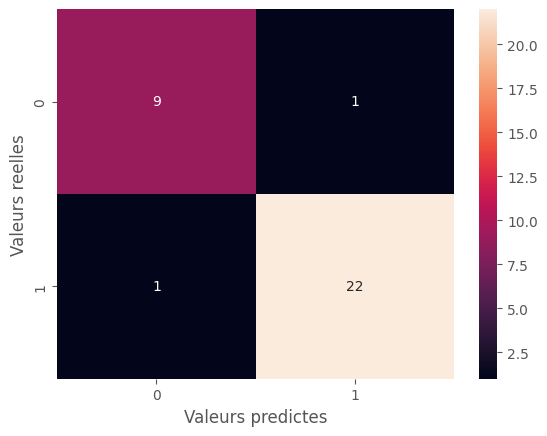

In [38]:
# Plot la matrice de confusion avec heatmap de sns
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Valeurs predictes')
plt.ylabel('Valeurs reelles')
plt.show()

In [39]:
#  Accuracy
print(f"Accuracy : {accuracy_score(y_test, y_pred)}")

Accuracy : 0.9393939393939394


In [40]:
# Precision
print(f"Precision : {precision_score(y_test, y_pred)}")

Precision : 0.9565217391304348


In [41]:
# Recall
print(f"Recall : {recall_score(y_test, y_pred)}")

Recall : 0.9565217391304348


In [42]:
# F1 score
print(f"F1 score : {f1_score(y_test, y_pred)}")

F1 score : 0.9565217391304348


In [43]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.96      0.96      0.96        23

    accuracy                           0.94        33
   macro avg       0.93      0.93      0.93        33
weighted avg       0.94      0.94      0.94        33



In [44]:
# coeffs appris et odds ratio
coefs = pd.DataFrame(lrc.coef_, columns=X.columns)
coefs.T

,0
Age,1.055003
Income,0.988112
Number_of_Children,0.089584
Gender_Female,-0.169325
Gender_Male,0.155557
Education_Associate's Degree,-0.856171
Education_Bachelor's Degree,0.022200
Education_Doctorate,0.373063
Education_High School Diploma,-0.283354
Education_Master's Degree,0.730494


In [45]:
odds_ratio = np.exp(coefs)
odds_ratio.T

,0
Age,2.871984
Income,2.686157
Number_of_Children,1.093719
Gender_Female,0.844235
Gender_Male,1.168308
Education_Associate's Degree,0.424785
Education_Bachelor's Degree,1.022448
Education_Doctorate,1.452176
Education_High School Diploma,0.753253
Education_Master's Degree,2.076106


Le choix de la méthode de **validation croisée** dépend du jeu de données utilisé.  
Une technique efficace sur un jeu de données donné **ne sera pas forcément optimale** sur un autre.  
Cependant, il existe des techniques populaires qui sont largement utilisées :

- **k-fold cross-validation**
- **stratified k-fold cross-validation**

La validation croisée consiste à **diviser les données d'entraînement en plusieurs sous-ensembles**.  
On entraîne le modèle sur une partie de ces sous-ensembles et on le teste sur les autres.

<br>

<img src="https://i.stack.imgur.com/8uEci.png" width=50%>

---

## 1. k-fold cross-validation

Comme illustré ci-dessus, les échantillons (et les cibles associées) sont divisés en `k` sous-ensembles **exclusifs**.  
C’est ce qu’on appelle la **validation croisée en k-plis** (*k-fold*).  
Chaque point de donnée est affecté à un des `k` groupes (de 0 à k−1), et chaque pli est utilisé comme ensemble de test une fois.

👉 Vous pouvez facilement implémenter cela avec `KFold` de `scikit-learn`.

---

## 2. Stratified k-fold cross-validation

Si votre jeu de données est **déséquilibré**, par exemple avec **90% de classes positives** et **10% de classes négatives**,  
alors utiliser une k-fold classique de manière aléatoire peut poser problème.

📉 En effet, certaines divisions peuvent contenir uniquement des exemples d’une seule classe, ce qui **fausse les métriques**.

➡️ Dans ce cas, on utilise la **stratified k-fold cross-validation** :  
elle conserve **la proportion de chaque classe constante** dans chaque pli.  
Par exemple, chaque sous-ensemble contiendra **environ 90% de positifs et 10% de négatifs**.

✅ Cela garantit une évaluation **plus stable et représentative**, peu importe la métrique utilisée (AUC, F1, etc.).

---

🎯 **Résumé** :

| Situation                          | Méthode recommandée            |
|-----------------------------------|--------------------------------|
| Données équilibrées               | ✅ k-fold classique             |
| Données déséquilibrées (ex : 90/10) | ✅ stratified k-fold (préserv. des classes) |


In [46]:
from sklearn.model_selection import KFold, StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    clr = LogisticRegression()
    clr.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = clr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_LR",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)

metrics_df = pd.DataFrame(metrics_list)
print("\nResume des metriques : ")
print(metrics_df)
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())

This is fold: 1
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 2
Matrice de confusion
 [[ 9  1]
 [ 2 21]]
----------
This is fold: 3
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 4
Matrice de confusion
 [[10  1]
 [ 1 21]]
----------
This is fold: 5
Matrice de confusion
 [[10  0]
 [ 1 21]]
----------

Resume des metriques : 
      model  fold  accuracy  precision    recall  f1_score   roc_auc
0  model_LR     1  1.000000   1.000000  1.000000  1.000000  1.000000
1  model_LR     2  0.909091   0.954545  0.913043  0.933333  0.906522
2  model_LR     3  1.000000   1.000000  1.000000  1.000000  1.000000
3  model_LR     4  0.939394   0.954545  0.954545  0.954545  0.931818
4  model_LR     5  0.968750   1.000000  0.954545  0.976744  0.977273

Moyenne des metriques : 
          fold  accuracy  precision    recall  f1_score   roc_auc
model                                                            
model_LR   3.0  0.963447   0.981818  0.964427  0.972925  0.9631

## 2.Using Naive Bayers

<img src="https://insightimi.files.wordpress.com/2020/04/unnamed-1.png">

2. Naïve Bayes (ex. : `GaussianNB`)

- **Principe** :  
  Basé sur le **théorème de Bayes** :  

  $$
  P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}
  $$

  Il suppose que toutes les variables sont **indépendantes** les unes des autres (hypothèse "naïve").  
  - `GaussianNB` : suppose que les variables suivent une loi normale (gaussienne).

- **Avantages** :  
  - Très rapide à entraîner et prédire.  
  - Fonctionne bien même avec peu de données.  
  - Gère naturellement les données textuelles (via fréquences).  

- **Limites** :  
  - L’hypothèse d’indépendance est souvent **fausse**.  
  - Performances limitées sur des données fortement corrélées.  

- **Cas d’usage** :  
  - Filtrage d’emails (spam vs non spam).  
  - Classification de texte, NLP.  

In [47]:
# from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#metrics_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    cnb = GaussianNB()
    cnb.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = cnb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_NB",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)

metrics_df = pd.DataFrame(metrics_list)
print("\nResume des metriques : ")
print(metrics_df)
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())

This is fold: 1
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 2
Matrice de confusion
 [[ 9  1]
 [ 0 23]]
----------
This is fold: 3
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 4
Matrice de confusion
 [[10  1]
 [ 1 21]]
----------
This is fold: 5
Matrice de confusion
 [[10  0]
 [ 1 21]]
----------

Resume des metriques : 
      model  fold  accuracy  precision    recall  f1_score   roc_auc
0  model_LR     1  1.000000   1.000000  1.000000  1.000000  1.000000
1  model_LR     2  0.909091   0.954545  0.913043  0.933333  0.906522
2  model_LR     3  1.000000   1.000000  1.000000  1.000000  1.000000
3  model_LR     4  0.939394   0.954545  0.954545  0.954545  0.931818
4  model_LR     5  0.968750   1.000000  0.954545  0.976744  0.977273
5  model_NB     1  1.000000   1.000000  1.000000  1.000000  1.000000
6  model_NB     2  0.969697   0.958333  1.000000  0.978723  0.950000
7  model_NB     3  1.000000   1.000000  1.000000  1.000000  1.000000
8  model_NB   

## 3.Using SVM(Support Vector Machines):

3. SVM — Support Vector Machines (avec différents noyaux)

- **Principe** :  
  Le SVM cherche à **séparer les classes** en trouvant un **hyperplan** qui maximise la **marge** (distance entre les classes et l’hyperplan).  

  - **Kernel linéaire** : sépare les classes avec une droite (2D) ou un plan (3D).  
  - **Kernel polynomial / RBF (Radial Basis Function)** : permet de séparer des classes **non linéaires** en projetant les données dans un espace de dimension supérieure.  

- **Avantages** :  
  - Très efficace sur des données complexes.  
  - Fonctionne bien avec peu d’exemples mais de nombreuses variables.  
  - Flexible grâce aux différents noyaux (kernel).  

- **Limites** :  
  - Peut être lent sur de très grands jeux de données.  
  - Les paramètres (C, gamma, degré) nécessitent du tuning.  
  - Moins interprétable.  

- **Cas d’usage** :  
  - Reconnaissance d’images (visages, chiffres manuscrits).  
  - Données complexes où les classes ne sont pas séparables linéairement.  

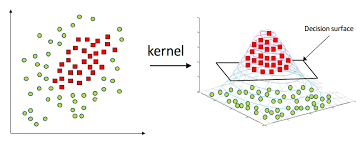

In [48]:
# from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#metrics_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    csvc_l = SVC(kernel = "linear")
    csvc_l.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = csvc_l.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_SVC_l",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)

metrics_df = pd.DataFrame(metrics_list)
print("\nResume des metriques : ")
print(metrics_df)
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())

This is fold: 1
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 2
Matrice de confusion
 [[ 9  1]
 [ 2 21]]
----------
This is fold: 3
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 4
Matrice de confusion
 [[10  1]
 [ 1 21]]
----------
This is fold: 5
Matrice de confusion
 [[10  0]
 [ 1 21]]
----------

Resume des metriques : 
          model  fold  accuracy  precision    recall  f1_score   roc_auc
0      model_LR     1  1.000000   1.000000  1.000000  1.000000  1.000000
1      model_LR     2  0.909091   0.954545  0.913043  0.933333  0.906522
2      model_LR     3  1.000000   1.000000  1.000000  1.000000  1.000000
3      model_LR     4  0.939394   0.954545  0.954545  0.954545  0.931818
4      model_LR     5  0.968750   1.000000  0.954545  0.976744  0.977273
5      model_NB     1  1.000000   1.000000  1.000000  1.000000  1.000000
6      model_NB     2  0.969697   0.958333  1.000000  0.978723  0.950000
7      model_NB     3  1.000000   1.000000  1.00000

In [49]:
# from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#metrics_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    csvc_s = SVC(kernel = "sigmoid")
    csvc_s.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = csvc_s.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_SVC_sig",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    """
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)
    """

metrics_df = pd.DataFrame(metrics_list)
"""
print("\nResume des metriques : ")
print(metrics_df)
"""
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())



Moyenne des metriques : 
               fold  accuracy  precision    recall  f1_score   roc_auc
model                                                                 
model_LR        3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_NB        3.0  0.975568   0.982576  0.981818  0.982003  0.971818
model_SVC_l     3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_sig   3.0  0.963447   0.981818  0.964427  0.972925  0.963123


In [50]:
# from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#metrics_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    csvc_r = SVC(kernel = "rbf")
    csvc_r.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = csvc_r.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_SVC_rbf",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)

metrics_df = pd.DataFrame(metrics_list)
print("\nResume des metriques : ")
print(metrics_df)
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())

This is fold: 1
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 2
Matrice de confusion
 [[ 9  1]
 [ 2 21]]
----------
This is fold: 3
Matrice de confusion
 [[10  0]
 [ 0 23]]
----------
This is fold: 4
Matrice de confusion
 [[10  1]
 [ 1 21]]
----------
This is fold: 5
Matrice de confusion
 [[10  0]
 [ 1 21]]
----------

Resume des metriques : 
            model  fold  accuracy  precision    recall  f1_score   roc_auc
0        model_LR     1  1.000000   1.000000  1.000000  1.000000  1.000000
1        model_LR     2  0.909091   0.954545  0.913043  0.933333  0.906522
2        model_LR     3  1.000000   1.000000  1.000000  1.000000  1.000000
3        model_LR     4  0.939394   0.954545  0.954545  0.954545  0.931818
4        model_LR     5  0.968750   1.000000  0.954545  0.976744  0.977273
5        model_NB     1  1.000000   1.000000  1.000000  1.000000  1.000000
6        model_NB     2  0.969697   0.958333  1.000000  0.978723  0.950000
7        model_NB     3  1.000000  

## Using K-nearest Neighbors
T4. k-Nearest Neighbors (k-NN)

- **Principe** :  
  Non paramétrique, simple :  
  - Pour une nouvelle observation, on regarde les **k voisins les plus proches** dans l’espace des données.  
  - La classe majoritaire de ces voisins est attribuée à l’observation.  

- **Avantages** :  
  - Facile à comprendre et implémenter.  
  - Pas d’entraînement complexe (lazy learner).  
  - S’adapte aux données non linéaires.  

- **Limites** :  
  - Coût élevé en prédiction (doit comparer avec tous les points).  
  - Sensible au **choix de k** et à la **mise à l’échelle** des variables.  
  - Performances faibles si beaucoup de variables (**malédiction de la dimensionnalité**).  

- **Cas d’usage** :  
  - Recommandation (utilisateurs similaires).  
  - Problèmes où la proximité entre points est significative.
  
<img src="http://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png">


In [51]:
# from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    cknc = KNeighborsClassifier(n_neighbors= 5)
    cknc.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = cknc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_knc",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    """
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)
    """

metrics_df = pd.DataFrame(metrics_list)
"""
print("\nResume des metriques : ")
print(metrics_df)
"""
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())


Moyenne des metriques : 
               fold  accuracy  precision    recall  f1_score   roc_auc
model                                                                 
model_LR        3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_NB        3.0  0.975568   0.982576  0.981818  0.982003  0.971818
model_SVC_l     3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_rbf   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_sig   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_knc       3.0  0.963447   0.981818  0.964427  0.972925  0.963123


# TREE BASED ALGORITHM
<img src="https://media.giphy.com/media/IyZM6HFe2zgrK/giphy.gif">

## Using Decission tree Classifier
A decision tree is a supervised learning algorithm that is perfect for classification problems, as it’s able to order classes on a precise level. It works like a flow chart, separating data points into two similar categories at a time from the “tree trunk” to “branches,” to “leaves,” where the categories become more finitely similar. This creates categories within categories, allowing for organic classification with limited human supervision.

In [52]:
df_tree.head()

,Age,Gender,Income,Education,Marital_Status,Number_of_Children,Home_Ownership,got_credit
0,25,0,50000,1,1,0,1,1
1,30,1,100000,4,0,2,0,1
2,35,0,75000,2,0,1,0,1
3,40,1,125000,3,1,0,0,1
4,45,0,100000,1,0,3,0,1


In [53]:
# Separer les donnees
X = df_tree.drop('got_credit', axis=1).copy()
y = df_tree['got_credit'].copy()

In [54]:
from sklearn.tree import DecisionTreeClassifier
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    cdtc = DecisionTreeClassifier(criterion="entropy")
    cdtc.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = cdtc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_dtc",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    """
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)
    """

metrics_df = pd.DataFrame(metrics_list)
"""
print("\nResume des metriques : ")
print(metrics_df)
"""
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())


Moyenne des metriques : 
               fold  accuracy  precision    recall  f1_score   roc_auc
model                                                                 
model_LR        3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_NB        3.0  0.975568   0.982576  0.981818  0.982003  0.971818
model_SVC_l     3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_rbf   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_sig   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_dtc       3.0  0.981818   0.991304  0.982213  0.986653  0.981107
model_knc       3.0  0.963447   0.981818  0.964427  0.972925  0.963123


In [55]:
X.columns

Index(['Age', 'Gender', 'Income', 'Education', 'Marital_Status',
       'Number_of_Children', 'Home_Ownership'],
      dtype='object')

In [56]:
df_tree['Home_Ownership'].value_counts()

,count
Home_Ownership,
0,111
1,53


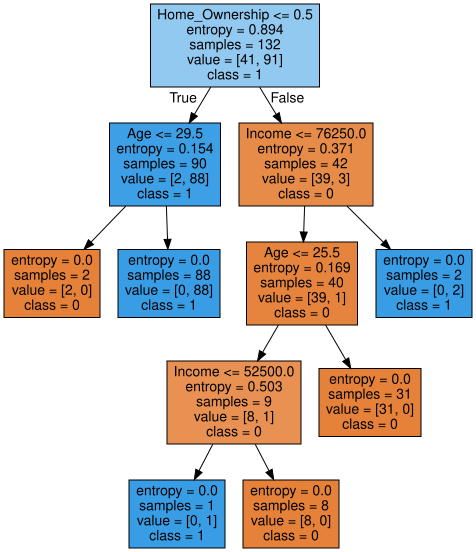

In [57]:
# Visualiser l'arbre de decision construit
from sklearn.tree import export_graphviz
import graphviz

notre_arbre = export_graphviz(cdtc, out_file = None,
                                   feature_names = X.columns,
                                   class_names = ['0', '1'],
                                   filled = True)

graph = graphviz.Source(notre_arbre)
graph

In [58]:
# Sauvegarder l'arbre
graph.render("arbre_decision_cdtc")

'arbre_decision_cdtc.pdf'

In [59]:
graph.render("arbre_decision_cdtc", format = "png")

'arbre_decision_cdtc.png'

In [60]:
from sklearn import tree
# Version texte rapide des regles de decisions
r = tree.export_text(cdtc, feature_names = list(X.columns))
print(r)

|--- Home_Ownership <= 0.50
|   |--- Age <= 29.50
|   |   |--- class: 0
|   |--- Age >  29.50
|   |   |--- class: 1
|--- Home_Ownership >  0.50
|   |--- Income <= 76250.00
|   |   |--- Age <= 25.50
|   |   |   |--- Income <= 52500.00
|   |   |   |   |--- class: 1
|   |   |   |--- Income >  52500.00
|   |   |   |   |--- class: 0
|   |   |--- Age >  25.50
|   |   |   |--- class: 0
|   |--- Income >  76250.00
|   |   |--- class: 1



In [61]:
from sklearn.tree import _tree
def rules_simple(model, feature_names, class_names):
    tree_ = model.tree_
    rules = []

    def recurse(node, path) :
        if tree_.feature[node] != _tree.TREE_UNDEFINED :
            name = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], path + [f"{name} <= {threshold:.2f}"])
            recurse(tree_.children_right[node], path + [f"{name} > {threshold:.2f}"])
        else :
            value = tree_.value[node][0]
            proba = value / value.sum()
            pred = class_names[proba.argmax()]
            rules.append(f"IF {' AND '.join(path)} THEN {pred}, proba = {proba}")

    recurse(0, [])
    return rules

In [62]:
rules = rules_simple(cdtc, X.columns, ['0', '1'])
n = 1
for r in rules :
  print("Regle : ", n)
  print(r)
  n += 1

Regle :  1
IF Home_Ownership <= 0.50 AND Age <= 29.50 THEN 0, proba = [1. 0.]
Regle :  2
IF Home_Ownership <= 0.50 AND Age > 29.50 THEN 1, proba = [0. 1.]
Regle :  3
IF Home_Ownership > 0.50 AND Income <= 76250.00 AND Age <= 25.50 AND Income <= 52500.00 THEN 1, proba = [0. 1.]
Regle :  4
IF Home_Ownership > 0.50 AND Income <= 76250.00 AND Age <= 25.50 AND Income > 52500.00 THEN 0, proba = [1. 0.]
Regle :  5
IF Home_Ownership > 0.50 AND Income <= 76250.00 AND Age > 25.50 THEN 0, proba = [1. 0.]
Regle :  6
IF Home_Ownership > 0.50 AND Income > 76250.00 THEN 1, proba = [0. 1.]


## Using Random Forest Classifier

La forêt aléatoire (random forest), comme son nom l’indique, est constituée d’un grand nombre d’arbres de décision individuels qui fonctionnent ensemble en ensemble (ensemble learning).
Chaque arbre de la forêt produit une prédiction de classe, et la classe qui obtient le plus de votes devient la prédiction finale du modèle (voir figure ci-dessous).

<img src="https://miro.medium.com/max/5752/1*5dq_1hnqkboZTcKFfwbO9A.png" width=70%>

Le concept fondamental derrière la forêt aléatoire est simple mais puissant : c’est celui de la sagesse des foules.
En termes de science des données, la raison pour laquelle le modèle de forêt aléatoire fonctionne si bien est la suivante :

Un grand nombre de modèles relativement non corrélés (arbres), qui fonctionnent comme un comité, surpasseront chacun des modèles pris individuellement.

La faible corrélation entre les modèles est la clé.
De la même façon que des investissements faiblement corrélés (comme les actions et les obligations) se combinent pour former un portefeuille dont la valeur est supérieure à la somme de ses parties, des modèles non corrélés peuvent produire des prédictions d’ensemble plus précises que n’importe quelle prédiction isolée.

La raison de cet effet remarquable est que les arbres se protègent mutuellement de leurs erreurs individuelles (tant qu’ils ne se trompent pas tous dans la même direction).
Ainsi, même si certains arbres se trompent, beaucoup d’autres auront raison ; et en groupe, les arbres parviennent à orienter la prédiction finale dans la bonne direction.

In [63]:
from sklearn.ensemble import RandomForestClassifier
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    crfc = RandomForestClassifier(n_estimators= 20, criterion="entropy")
    crfc.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = crfc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_rfc",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    """
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)
    """

metrics_df = pd.DataFrame(metrics_list)
"""
print("\nResume des metriques : ")
print(metrics_df)
"""
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())


Moyenne des metriques : 
               fold  accuracy  precision    recall  f1_score   roc_auc
model                                                                 
model_LR        3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_NB        3.0  0.975568   0.982576  0.981818  0.982003  0.971818
model_SVC_l     3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_rbf   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_sig   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_dtc       3.0  0.981818   0.991304  0.982213  0.986653  0.981107
model_knc       3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_rfc       3.0  0.981818   0.991304  0.982213  0.986653  0.981107


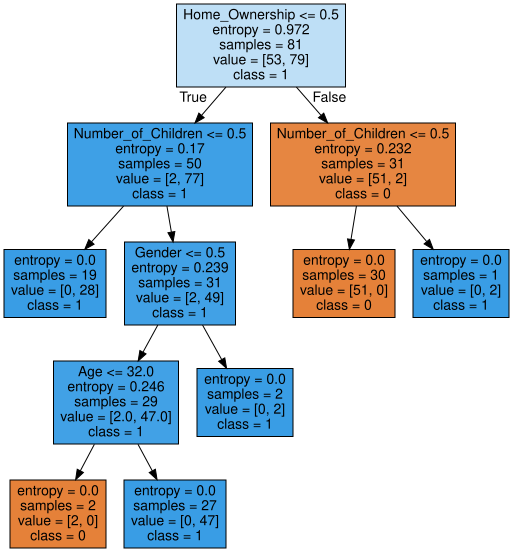

In [65]:
est0 = crfc.estimators_[0]
notre_arbre2 = export_graphviz(est0, out_file = None,
                                   feature_names = X.columns,
                                   class_names = ['0', '1'],
                                   filled = True)

graph2 = graphviz.Source(notre_arbre2)
graph2

## Using XGBoost

---

## 🌳 1. Qu’est-ce que XGBoost ?

* **XGBoost** signifie **eXtreme Gradient Boosting**.
* C’est un algorithme de type **boosting par gradient**, très populaire en machine learning car il est **rapide, performant et efficace**.
* Il est souvent utilisé en compétition (ex. Kaggle) et en pratique (banques, santé, environnement…) pour des problèmes de classification et de régression.

---

## ⚡ 2. Différence avec Random Forest

* **Random Forest** = plein d’arbres indépendants, qui votent (**vote majoritaire**).
* **XGBoost** = arbres construits **l’un après l’autre**. Chaque nouvel arbre corrige les erreurs du précédent (**boosting séquentiel**).
  👉 Random Forest = **sagesse des foules** ;
  👉 XGBoost = **travail en équipe séquentiel**.

---

## 🛠️ 3. Comment ça marche ?

1. On commence avec un modèle simple (par ex. prédire la moyenne de y).
2. On calcule l’erreur (résidus = vraie valeur – prédiction).
3. On construit un nouvel arbre de décision qui essaie de prédire **ces erreurs**.
4. On met à jour la prédiction globale en ajoutant cet arbre, avec un petit **taux d’apprentissage** (*learning rate*).
5. On répète le processus → chaque arbre vient affiner le modèle.

Résultat : une série d’arbres faibles (peu profonds) qui, ensemble, deviennent **un modèle très puissant**.

---

## 🔍 4. Les arbres CART dans XGBoost

* Les arbres utilisés sont des **CART (Classification And Regression Trees)**.
* Contrairement aux arbres classiques où chaque feuille donne une classe, ici chaque feuille donne un **score numérique**.
* Ces scores sont ensuite combinés (somme pondérée) pour produire la prédiction finale.
* Si c’est une classification, on applique une fonction (ex. **sigmoïde** pour binaire) pour transformer le score en probabilité.

---

## 🧩 5. Atouts de XGBoost

* **Performance** : excellent pouvoir prédictif.
* **Gestion des valeurs manquantes** automatique.
* **Parallélisation** → très rapide.
* **Régularisation intégrée** (évite l’overfitting, contrairement aux arbres simples).
* Compatible **classification, régression, ranking**.

In [66]:
from xgboost import XGBClassifier
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Recuperer les splits
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrainer le model
    cxgbc = XGBClassifier()
    cxgbc.fit(X_train, y_train)

    # Calculer les metriques
    y_pred = cxgbc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Sauvegarder les metriques
    metrics_list.append({
        "model": "model_xgbc",
        "fold": fold +1,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
        })
    """
    print(f"This is fold: {fold +1}")
    cm = confusion_matrix(y_test, y_pred)
    print("Matrice de confusion\n", cm)
    print("-"*10)
    """

metrics_df = pd.DataFrame(metrics_list)
"""
print("\nResume des metriques : ")
print(metrics_df)
"""
print("\nMoyenne des metriques : ")
print(metrics_df.groupby("model").mean())


Moyenne des metriques : 
               fold  accuracy  precision    recall  f1_score   roc_auc
model                                                                 
model_LR        3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_NB        3.0  0.975568   0.982576  0.981818  0.982003  0.971818
model_SVC_l     3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_rbf   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_SVC_sig   3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_dtc       3.0  0.981818   0.991304  0.982213  0.986653  0.981107
model_knc       3.0  0.963447   0.981818  0.964427  0.972925  0.963123
model_rfc       3.0  0.981818   0.991304  0.982213  0.986653  0.981107
model_xgbc      3.0  0.975379   0.975000  0.990909  0.982398  0.965455


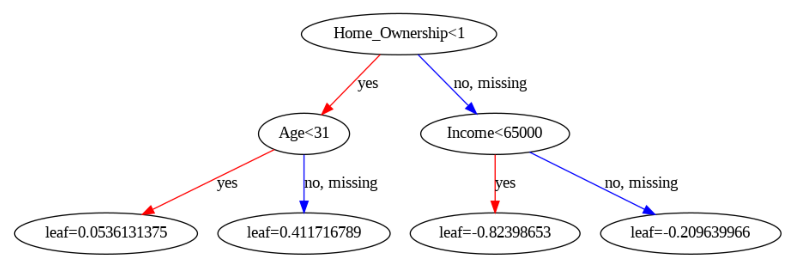

In [67]:
fig, ax = plt.subplots(figsize=(10, 10))
from xgboost import plot_tree
plot_tree(cxgbc, num_trees=0, ax=ax)
plt.show()

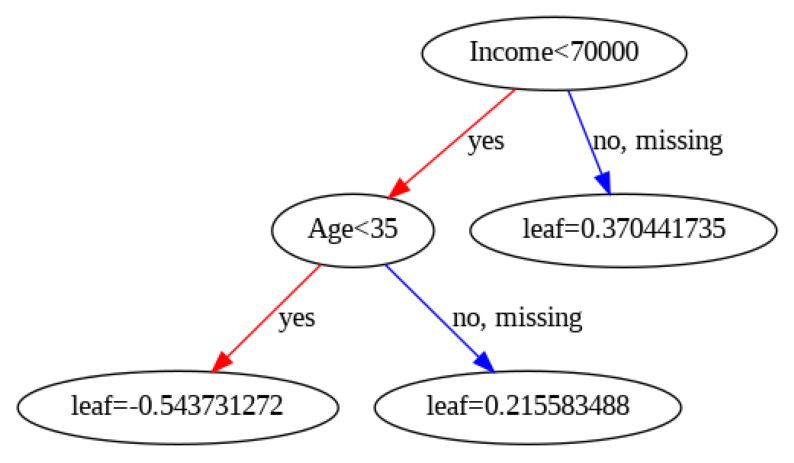

In [68]:
fig, ax = plt.subplots(figsize=(10, 10))
from xgboost import plot_tree
plot_tree(cxgbc, num_trees=1, ax=ax)
plt.show()

# **Optimisation**